In [5]:
import pandas as pd

In [6]:
df=pd.read_excel("PAP 02 data for TAS204040 overall data for model building - 2.xlsx")


In [7]:
df.shape

(10850, 51)

In [8]:
print(df.columns.tolist())

['Date', 'Weigh feeder rate AJD2706A-WIC.PV', 'Weigh feeder rate BJD2706B-WIC.PV', 'Ball mill ampsPA2729A-AI', 'BALL MILL VENT SYS TEMPTI2705.PV', 'BALL MILL VENT FAN CURRENTGB2705-AI.PV', 'BAG FLTR SUC PRESSUREPI2705A.PV', 'FAN SUC PRESSUREPI2705C.PV', 'SCREW CONV - CURRENTJD2709-AI.PV', 'BUCKET ELEVATOR CURRENTJD2710-AI.PV', 'WEIGH FDR A FEED RATEJD2715A-WIC.PV', 'WEIGH FDR B FEED RATEJD2715B-WIC.PV', 'H2SO4 TO ATTACK RCT A FLOWFIC2802.PV', 'H2SO4 TO ATTACK RCT B FLOWFIC2803.PV', 'RECYCL ACD ATTACK RCT A FLOWFIC2804.PV', 'RECYCL ACD ATTACK RCT B FLOWFIC2805.PV', 'ATTACK AGTR A CURRENTGD2801A-AI.PV', 'ATTACK AGTR B CURRENTGD2801B-AI.PV', 'ATTACK AGTR C CURRENTGD2801C-AI.PV', 'ATTACK AGTR D CURRENTGD2801D-AI.PV', 'ATTACK RCT B TEMPTI2801B.PV', 'ATTACK RCT D TEMPTI2801D.PV', 'Filter SPGPA2_FILSPG', 'Slurry SPGPA2_SLURRYSPG', 'Free AcidPA2_FREEACID', 'Reactor SolidsREACT-SOLIDS.PV', 'NEW DIGESTION TANK LEVELLI2802.PV', 'LOW LVL FLASH COOLER VACUUMPIC2801.PV', 'TD LLFC I/L & O/L TEMPTDY28

In [9]:
target_cols = [
    "Filter SPGPA2_FILSPG",
    "Slurry SPGPA2_SLURRYSPG",
    "Free AcidPA2_FREEACID",
    "No 1 filtrate %P2O5",
    "No 1 filtrate Sp Gr",
    "No 1 filtrate FREEACID",
    "Gypsum TP2O5 loss"
]

feature_cols = [
    col for col in df.columns
    if col not in target_cols
]

print("Feature Columns :", len(feature_cols))
print("Target Columns :", len(target_cols))

Feature Columns : 44
Target Columns : 7


In [10]:

missing = df[feature_cols].isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [11]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [12]:
df[feature_cols].dtypes.value_counts()

float64           39
object             4
datetime64[ns]     1
Name: count, dtype: int64

In [13]:
object_cols = df[feature_cols].select_dtypes(include="object").columns

print(object_cols.tolist())

['RECYCL ACD ATTACK RCT B FLOWFIC2805.PV', 'HBF support fanGB2902-AI', 'Weak wash flowFIC2907', 'Cake wash temperatureTI2908']


In [14]:
object_cols.tolist()

['RECYCL ACD ATTACK RCT B FLOWFIC2805.PV',
 'HBF support fanGB2902-AI',
 'Weak wash flowFIC2907',
 'Cake wash temperatureTI2908']

In [15]:
for col in object_cols:
    print("\n", "="*60)
    print("COLUMN :", col)
    print(df[col].head(10))


COLUMN : RECYCL ACD ATTACK RCT B FLOWFIC2805.PV
0     155.86059
1    155.729849
2    156.217867
3    155.777613
4    156.429135
5    156.213995
6    155.968487
7    156.133444
8    156.044965
9    156.277248
Name: RECYCL ACD ATTACK RCT B FLOWFIC2805.PV, dtype: object

COLUMN : HBF support fanGB2902-AI
0    28.701143
1    28.552285
2    28.706453
3    28.695628
4    28.770045
5    28.707615
6    28.604572
7     28.69698
8    28.612165
9    28.707431
Name: HBF support fanGB2902-AI, dtype: object

COLUMN : Weak wash flowFIC2907
0     -0.668228
1     -0.744572
2     -0.631908
3     -0.529602
4     -0.629929
5     15.062498
6    190.494664
7    196.027116
8    196.036193
9    196.032499
Name: Weak wash flowFIC2907, dtype: object

COLUMN : Cake wash temperatureTI2908
0     46.46743
1    46.466528
2    46.636018
3    46.747643
4     46.80054
5    46.910492
6     47.01317
7     47.03064
8    47.023056
9    47.101363
Name: Cake wash temperatureTI2908, dtype: object


In [16]:
for col in object_cols:
    print("\n", "="*60)
    print("COLUMN :", col)
    print(df[col].dropna().unique()[:20])


COLUMN : RECYCL ACD ATTACK RCT B FLOWFIC2805.PV
[155.8605900431017 155.72984897713232 156.2178666977209 155.7776128825887
 156.429135445235 156.21399485606622 155.96848656452494 156.13344354123885
 156.04496465124615 156.27724790204073 156.28177034806495
 155.80408197557446 155.90637167096259 155.76119882459753
 155.74174145565678 156.0651127088291 156.55907378558962 157.067478328334
 156.2737410577926 155.84327470451245]

COLUMN : HBF support fanGB2902-AI
[28.7011434749059 28.552284569684975 28.706452804227684 28.695628256745533
 28.77004485255702 28.70761468573934 28.60457224366813 28.69697981874051
 28.612165408947373 28.707431144889497 28.66957141899807 28.9392185932796
 28.804709901626147 28.842128276294293 28.839497734396478
 28.888559143858824 28.8856911763105 28.808401970687314 28.886336194661272
 28.7117461835398]

COLUMN : Weak wash flowFIC2907
[-0.668227818843525 -0.7445716287763511 -0.6319078269375579
 -0.529602476867782 -0.6299288990436079 15.06249834266933
 190.494663754

In [17]:
for col in object_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [18]:
df[feature_cols].dtypes.value_counts()

float64           43
datetime64[ns]     1
Name: count, dtype: int64

In [19]:
for col in object_cols:
    print(col)
    print(df[col].isnull().sum())

RECYCL ACD ATTACK RCT B FLOWFIC2805.PV
1
HBF support fanGB2902-AI
6
Weak wash flowFIC2907
2
Cake wash temperatureTI2908
3


In [20]:
for col in object_cols:
    df[col] = df[col].fillna(df[col].median())

In [21]:
for col in object_cols:
    print(col, ":", df[col].isnull().sum())

RECYCL ACD ATTACK RCT B FLOWFIC2805.PV : 0
HBF support fanGB2902-AI : 0
Weak wash flowFIC2907 : 0
Cake wash temperatureTI2908 : 0


In [22]:
df[feature_cols].dtypes.value_counts()

float64           43
datetime64[ns]     1
Name: count, dtype: int64

In [23]:
df = df.drop(columns=["Date"])

In [24]:
print(df.shape)

df.dtypes.value_counts()

(10850, 50)


float64    50
Name: count, dtype: int64

In [25]:
target = "Free AcidPA2_FREEACID"

In [26]:
target_cols = [
    "Filter SPGPA2_FILSPG",
    "Slurry SPGPA2_SLURRYSPG",
    "Free AcidPA2_FREEACID",
    "No 1 filtrate %P2O5",
    "No 1 filtrate Sp Gr",
    "No 1 filtrate FREEACID",
    "Gypsum TP2O5 loss"
]

feature_cols = [
    col for col in df.columns
    if col not in target_cols
]

X = df[feature_cols]

y = df["Free AcidPA2_FREEACID"]

In [27]:
df_ml = df.copy()

object_cols = [
    'RECYCL ACD ATTACK RCT B FLOWFIC2805.PV',
    'HBF support fanGB2902-AI',
    'Weak wash flowFIC2907',
    'Cake wash temperatureTI2908'
]

for col in object_cols:
    df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')

df_ml = df_ml.fillna(df_ml.median(numeric_only=True))

In [28]:
print(df_ml.dtypes.value_counts())

float64    50
Name: count, dtype: int64


In [29]:
target = 'Free AcidPA2_FREEACID'

target_cols = [
    'Filter SPGPA2_FILSPG',
    'Slurry SPGPA2_SLURRYSPG',
    'Free AcidPA2_FREEACID',
    'No 1 filtrate %P2O5',
    'No 1 filtrate Sp Gr',
    'No 1 filtrate FREEACID',
    'Gypsum TP2O5 loss'
]

feature_cols = [
    col for col in df_ml.columns
    if col not in target_cols
]

X = df_ml[feature_cols]
y = df_ml[target]

print(X.shape)
print(y.shape)

(10850, 43)
(10850,)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8680, 43)
(2170, 43)


In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression()

model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Train R2 :", round(train_r2,4))
print("Test R2 :", round(test_r2,4))

Train R2 : 0.2941
Test R2 : 0.2426


In [32]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

alphas = [0.001, 0.01, 0.1, 1, 10, 100]

for a in alphas:

    model = Ridge(alpha=a)

    model.fit(X_train, y_train)

    train_r2 = r2_score(
        y_train,
        model.predict(X_train)
    )

    test_r2 = r2_score(
        y_test,
        model.predict(X_test)
    )

    print(
        f"Alpha={a}",
        f"Train={train_r2:.4f}",
        f"Test={test_r2:.4f}"
    )

Alpha=0.001 Train=0.2941 Test=0.2426
Alpha=0.01 Train=0.2941 Test=0.2426
Alpha=0.1 Train=0.2941 Test=0.2426
Alpha=1 Train=0.2941 Test=0.2425
Alpha=10 Train=0.2940 Test=0.2419
Alpha=100 Train=0.2931 Test=0.2389


In [33]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

alphas = [0.001, 0.01, 0.1, 1, 10]

for a in alphas:

    model = Lasso(alpha=a)

    model.fit(X_train, y_train)

    train_r2 = r2_score(
        y_train,
        model.predict(X_train)
    )

    test_r2 = r2_score(
        y_test,
        model.predict(X_test)
    )

    print(
        f"Alpha={a}",
        f"Train={train_r2:.4f}",
        f"Test={test_r2:.4f}"
    )

Alpha=0.001 Train=0.2910 Test=0.2357
Alpha=0.01 Train=0.2724 Test=0.2305
Alpha=0.1 Train=0.1410 Test=0.1448
Alpha=1 Train=0.0529 Test=0.0445
Alpha=10 Train=0.0000 Test=-0.0024


In [34]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score

alphas = [0.001, 0.01, 0.1]
ratios = [0.2, 0.5, 0.8]

for alpha in alphas:

    for ratio in ratios:

        model = ElasticNet(
            alpha=alpha,
            l1_ratio=ratio,
            random_state=42
        )

        model.fit(X_train, y_train)

        train_r2 = r2_score(
            y_train,
            model.predict(X_train)
        )

        test_r2 = r2_score(
            y_test,
            model.predict(X_test)
        )

        print(
            f"Alpha={alpha}",
            f"Ratio={ratio}",
            f"Train={train_r2:.4f}",
            f"Test={test_r2:.4f}"
        )

c:\anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.303e-02, tolerance: 3.592e-02
  model = cd_fast.enet_coordinate_descent(


Alpha=0.001 Ratio=0.2 Train=0.2934 Test=0.2401
Alpha=0.001 Ratio=0.5 Train=0.2923 Test=0.2374
Alpha=0.001 Ratio=0.8 Train=0.2912 Test=0.2356
Alpha=0.01 Ratio=0.2 Train=0.2895 Test=0.2353
Alpha=0.01 Ratio=0.5 Train=0.2837 Test=0.2336
Alpha=0.01 Ratio=0.8 Train=0.2773 Test=0.2324
Alpha=0.1 Ratio=0.2 Train=0.2431 Test=0.2146
Alpha=0.1 Ratio=0.5 Train=0.1864 Test=0.1766
Alpha=0.1 Ratio=0.8 Train=0.1573 Test=0.1570


In [35]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

for degree in [1, 2, 3]:

    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()

    model.fit(X_train_poly, y_train)

    train_r2 = r2_score(
        y_train,
        model.predict(X_train_poly)
    )

    test_r2 = r2_score(
        y_test,
        model.predict(X_test_poly)
    )

    print(
        f"Degree={degree}",
        f"Train={train_r2:.4f}",
        f"Test={test_r2:.4f}"
    )

Degree=1 Train=0.2941 Test=0.2426
Degree=2 Train=0.8743 Test=-1.9924
Degree=3 Train=1.0000 Test=-1707.7489


In [36]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

depths = [2, 5, 10, 20, 50, 100]

for d in depths:

    model = DecisionTreeRegressor(
        max_depth=d,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_r2 = r2_score(
        y_train,
        model.predict(X_train)
    )

    test_r2 = r2_score(
        y_test,
        model.predict(X_test)
    )

    print(
        f"Depth={d}",
        f"Train={train_r2:.4f}",
        f"Test={test_r2:.4f}"
    )

Depth=2 Train=0.2027 Test=0.1774
Depth=5 Train=0.4407 Test=0.3560
Depth=10 Train=0.8820 Test=0.7829
Depth=20 Train=0.9997 Test=0.8826
Depth=50 Train=1.0000 Test=0.8752
Depth=100 Train=1.0000 Test=0.8752


In [37]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

leaf_nodes = [5, 10, 20, 50, 100, 200]

for leaf in leaf_nodes:

    model = DecisionTreeRegressor(
        max_leaf_nodes=leaf,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_r2 = r2_score(
        y_train,
        model.predict(X_train)
    )

    test_r2 = r2_score(
        y_test,
        model.predict(X_test)
    )

    print(
        f"Leaf Nodes={leaf}",
        f"Train={train_r2:.4f}",
        f"Test={test_r2:.4f}"
    )

Leaf Nodes=5 Train=0.2452 Test=0.2301
Leaf Nodes=10 Train=0.3876 Test=0.3163
Leaf Nodes=20 Train=0.5384 Test=0.4777
Leaf Nodes=50 Train=0.7568 Test=0.6825
Leaf Nodes=100 Train=0.8761 Test=0.7726
Leaf Nodes=200 Train=0.9569 Test=0.8489


In [38]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

leaf_sizes = [1, 2, 5, 10, 20, 50]

for leaf_size in leaf_sizes:

    model = DecisionTreeRegressor(
        min_samples_leaf=leaf_size,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_r2 = r2_score(
        y_train,
        model.predict(X_train)
    )

    test_r2 = r2_score(
        y_test,
        model.predict(X_test)
    )

    print(
        f"MinSamplesLeaf={leaf_size}",
        f"Train={train_r2:.4f}",
        f"Test={test_r2:.4f}"
    )

MinSamplesLeaf=1 Train=1.0000 Test=0.8752
MinSamplesLeaf=2 Train=0.9953 Test=0.8799
MinSamplesLeaf=5 Train=0.9806 Test=0.8923
MinSamplesLeaf=10 Train=0.9555 Test=0.8651
MinSamplesLeaf=20 Train=0.9075 Test=0.8627
MinSamplesLeaf=50 Train=0.8061 Test=0.7639


In [39]:
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import r2_score

trees = [2, 5, 10, 20, 50, 100,200]

for t in trees:

    model = RandomForestRegressor(
        n_estimators=t,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_r2 = r2_score(
        y_train,
        model.predict(X_train)
    )

    test_r2 = r2_score(
        y_test,
        model.predict(X_test)
    )

    print(
        f"Trees={t}",
        f"Train={train_r2:.4f}",
        f"Test={test_r2:.4f}"
    )

Trees=2 Train=0.9696 Test=0.8822
Trees=5 Train=0.9842 Test=0.9350
Trees=10 Train=0.9895 Test=0.9500
Trees=20 Train=0.9935 Test=0.9611
Trees=50 Train=0.9953 Test=0.9648
Trees=100 Train=0.9960 Test=0.9677
Trees=200 Train=0.9961 Test=0.9685


In [41]:
import sys

print(sys.executable)

c:\anaconda\python.exe


In [42]:
import sys

!{sys.executable} -m pip install shap

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   ---------------------------------------- 0/2 [slicer]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ----------------

In [43]:
import shap

print(shap.__version__)

0.52.0


In [44]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [45]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

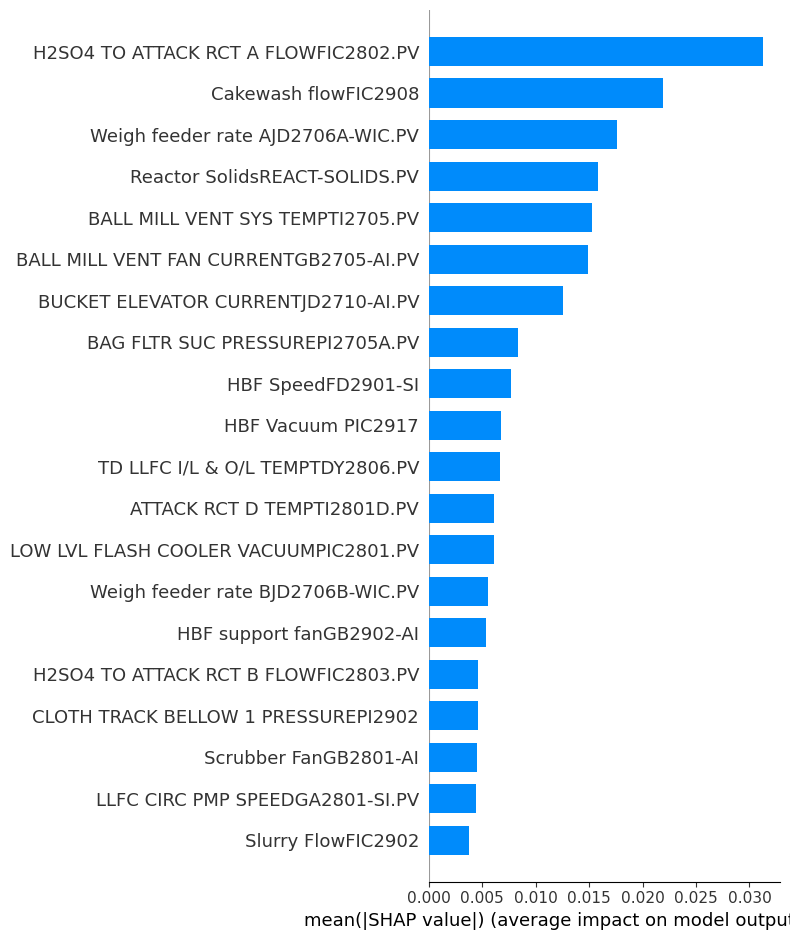

In [46]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

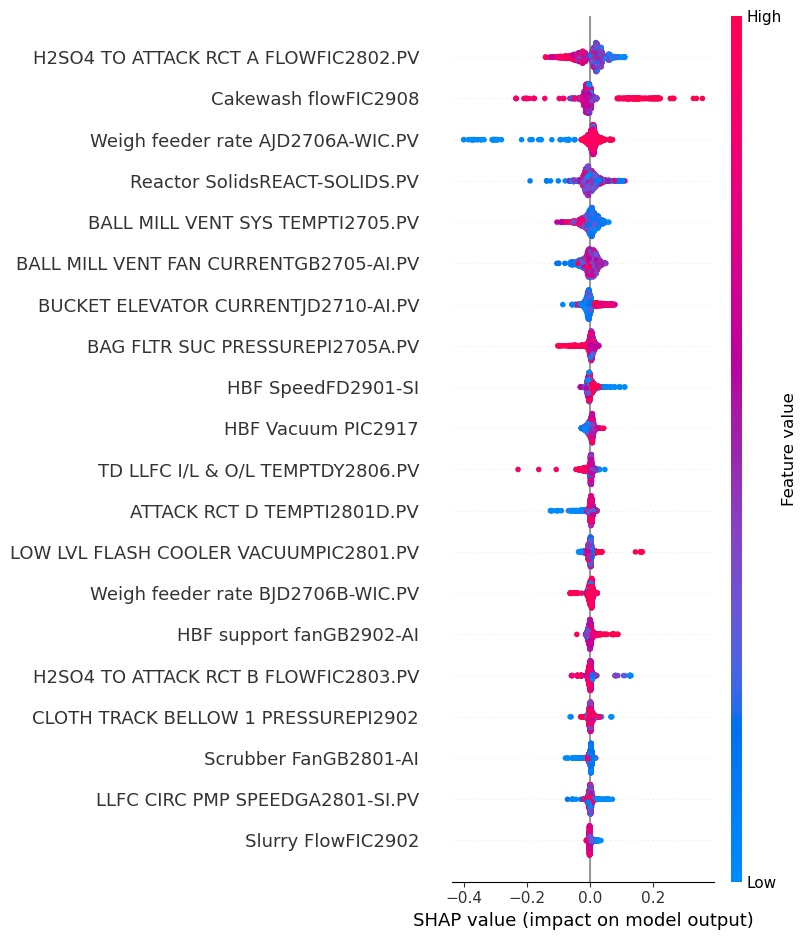

In [47]:
shap.summary_plot(
    shap_values,
    X_test
)

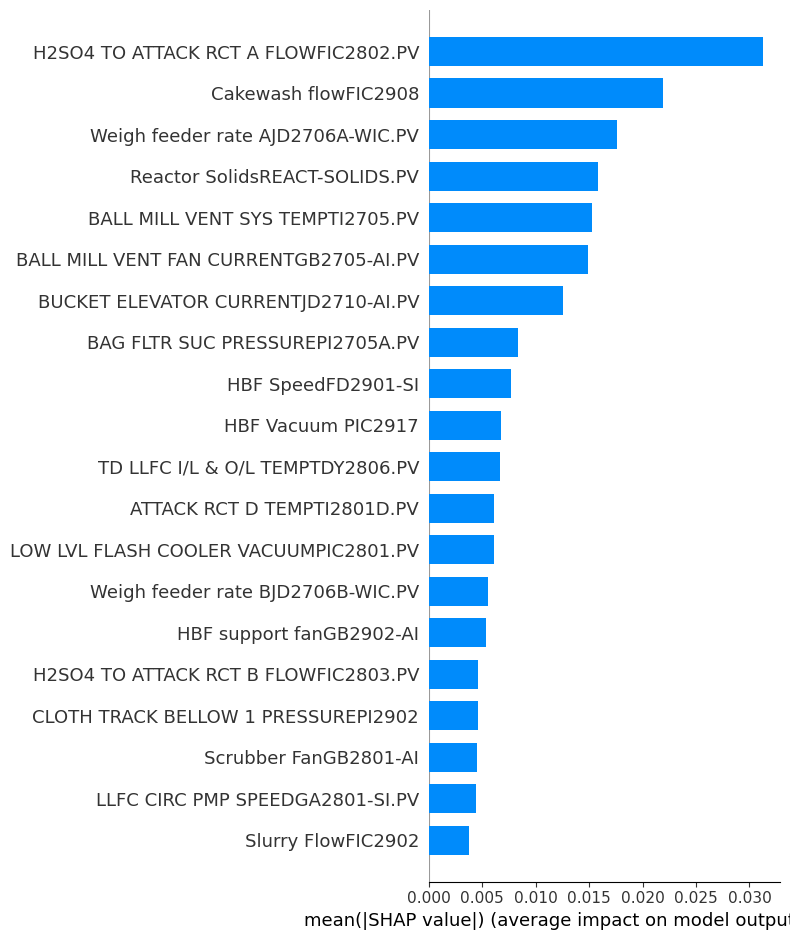

In [48]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [53]:
import pandas as pd
import numpy as np

shap_importance = pd.DataFrame({
    "Parameter": X_test.columns,
    "Mean_SHAP_Contribution": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="Mean_SHAP_Contribution",
    ascending=False
)

print(shap_importance)

                                 Parameter  Mean_SHAP_Contribution
11    H2SO4 TO ATTACK RCT A FLOWFIC2802.PV                0.031292
36                    Cakewash flowFIC2908                0.021887
0        Weigh feeder rate AJD2706A-WIC.PV                0.017627
21           Reactor SolidsREACT-SOLIDS.PV                0.015826
3         BALL MILL VENT SYS TEMPTI2705.PV                0.015300
4   BALL MILL VENT FAN CURRENTGB2705-AI.PV                0.014885
8      BUCKET ELEVATOR CURRENTJD2710-AI.PV                0.012550
5          BAG FLTR SUC PRESSUREPI2705A.PV                0.008372
31                      HBF SpeedFD2901-SI                0.007676
29                      HBF Vacuum PIC2917                0.006738
24        TD LLFC I/L & O/L TEMPTDY2806.PV                0.006662
20             ATTACK RCT D TEMPTI2801D.PV                0.006081
23   LOW LVL FLASH COOLER VACUUMPIC2801.PV                0.006052
1        Weigh feeder rate BJD2706B-WIC.PV                0.00